# Analysis of HFE Gamma Attenuation

This notebook analyzes the effects of HFE (hydrofluoroether) on background gammas in the nEXO experiment.

## Import necessary libraries

In [5]:
# Importing packages and classes
import json
import os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.size": 16,
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 14,
        "legend.title_fontsize": 16,
        "figure.figsize": (12, 8),
        # Grid settings
        "axes.grid": True,
        "grid.alpha": 0.7,
        "grid.linestyle": "--",
        # Minor ticks settings
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        # Ensure grid is shown for both major and minor ticks
        "axes.grid.which": "both",
    }
)

## HFE Gamma Attenuation Analysis

HFE thickness 76 cm:
 Intensity reduction factor: 4.8391e-03
 Gammas transmitted: 0.48%
 Gammas attenuated: 99.52%

HFE thickness 25 cm:
 Intensity reduction factor: 1.7314e-01
 Gammas transmitted: 17.31%
 Gammas attenuated: 82.69%



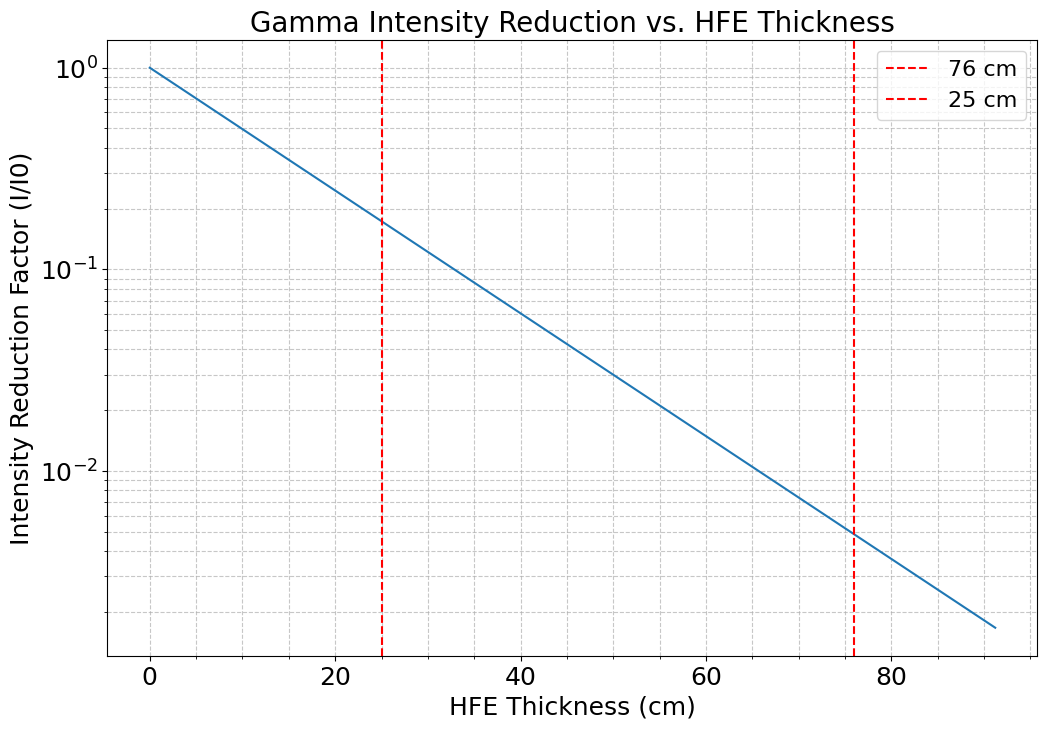

In [6]:
# HFE gamma attenuation

# Constants
HFE_DENSITY = 1.73012619  # g/cm^3 for HFE-7200 at 165 K
MASS_ATTENUATION_COEFF = 0.03898  # cm^2/g for 2.5 MeV gamma in HFE-7200

# Analyze for original and reduced thicknesses
thicknesses = [76, 25]

# Calculate and print results
for thickness in thicknesses:
    reduction = np.exp(-MASS_ATTENUATION_COEFF * HFE_DENSITY * thickness)
    print(f"HFE thickness {thickness} cm:")
    print(f" Intensity reduction factor: {reduction:.4e}")
    print(f" Gammas transmitted: {reduction*100:.2f}%")
    print(f" Gammas attenuated: {(1-reduction)*100:.2f}%\n")

# Plot intensity reduction vs. thickness
plot_thicknesses = np.linspace(0, max(thicknesses) * 1.2, 100)
intensities = np.exp(-MASS_ATTENUATION_COEFF * HFE_DENSITY * plot_thicknesses)

plt.figure()
plt.plot(plot_thicknesses, intensities)
for thickness in thicknesses:
    plt.axvline(x=thickness, color="r", linestyle="--", label=f"{thickness} cm")

plt.xlabel("HFE Thickness (cm)")
plt.ylabel("Intensity Reduction Factor (I/I0)")
plt.legend()
plt.yscale("log")
plt.title("Gamma Intensity Reduction vs. HFE Thickness")
plt.show()

## HFE Self-Shielding Analysis

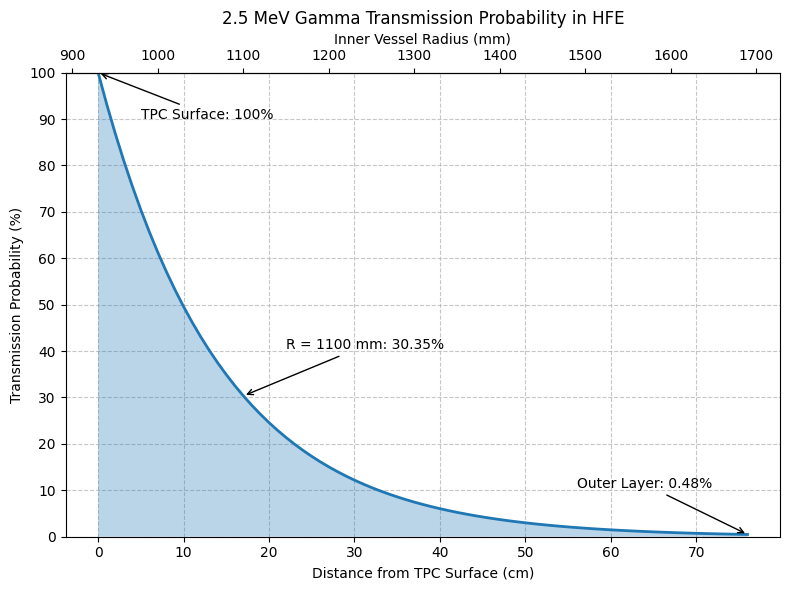

In [3]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt

# Constants
HFE_DENSITY = 1.73012619               # g/cm³ for HFE-7200 at 165 K
MASS_ATTENUATION_COEFF = 0.03898 # cm²/g for 2.5 MeV gamma in HFE-7200
hfe_thickness = 76               # cm

# Generate distances (0, 1, 2, …, 76 cm) and transmission probabilities
distances = np.linspace(0, hfe_thickness, hfe_thickness + 1)
probabilities = 100 * np.exp(-MASS_ATTENUATION_COEFF * HFE_DENSITY * distances)

# Create figure
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot transmission curve
ax1.plot(distances, probabilities, linewidth=2)
ax1.fill_between(distances, probabilities, alpha=0.3)

# Axis labels and title
ax1.set_xlabel("Distance from TPC Surface (cm)")
ax1.set_ylabel("Transmission Probability (%)")
ax1.set_title("2.5 MeV Gamma Transmission Probability in HFE")

# Ticks and grid
ax1.set_xticks(np.arange(0, hfe_thickness + 1, 10))
ax1.set_yticks(np.arange(0, 101, 10))
ax1.set_ylim(0, 100)
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.set_axisbelow(True)

# Secondary x-axis: map 0 cm → 930 mm up to 76 cm → 1690 mm
def cm_to_radius(x):
    return (1690 - 930) / 76 * x + 930

def radius_to_cm(x):
    return (x - 930) * 76 / (1690 - 930)

ax2 = ax1.secondary_xaxis("top", functions=(cm_to_radius, radius_to_cm))
ax2.set_xlabel("Inner Vessel Radius (mm)")

# Annotation at R = 1100 mm
target_radius_mm = 1100
cm_at_target    = radius_to_cm(target_radius_mm)
prob_target     = 100 * np.exp(-MASS_ATTENUATION_COEFF * HFE_DENSITY * cm_at_target)

annotations = [
    ("TPC Surface: 100%", (0, 100), (5, 90)),
    (
        f"R = {target_radius_mm} mm: {prob_target:.2f}%",
        (cm_at_target, prob_target),
        (cm_at_target + 5, prob_target + 10),
    ),
    (
        f"Outer Layer: {probabilities[-1]:.2f}%",
        (hfe_thickness, probabilities[-1]),
        (hfe_thickness - 20, probabilities[-1] + 10),
    ),
]

for text, xy, xytext in annotations:
    ax1.annotate(text, xy=xy, xytext=xytext, arrowprops=dict(arrowstyle="->"))

plt.tight_layout()
plt.show()


In [15]:
transmission_76cm = probabilities[-1]  # at 76cm
transmission_19_5cm = probabilities[19]  # at 19.5cm

# Compare how much more radiation gets through (transmission increase)
transmission_increase = transmission_19_5cm / transmission_76cm

print(f"Transmission at 76cm: {transmission_76cm:.2f}%")
print(f"Transmission at 19.5cm: {transmission_19_5cm:.2f}%")
print(f"Transmission increases by a factor of {transmission_increase:.1f}")

Transmission at 76cm: 0.48%
Transmission at 19.5cm: 25.91%
Transmission increases by a factor of 53.5


## Radon Background Attenuation Analysis

`calculate_max_rn_concentration` Function: Estimates maximum allowable ²²²Rn concentration in Outer Detector water for varying HFE thicknesses, maintaining constant background contribution.

Key Assumptions:
1. Reference point: 76 cm HFE, 9e-9 Bq/kg ²²²Rn
2. Product of water ²²²Rn concentration and gamma transmission through HFE remains constant

Calculation Method:
1. Uses Beer-Lambert law to calculate gamma transmission:
   ```
   transmission = exp(-μ * ρ * (reference_thickness - new_thickness))
   ```
2. Adjusts allowable ²²²Rn concentration based on transmission ratio:
   ```
   new_concentration = reference_concentration * transmission_ratio
   ```

Limitation:
Assumes linear relationship between ²²²Rn concentration and background contribution

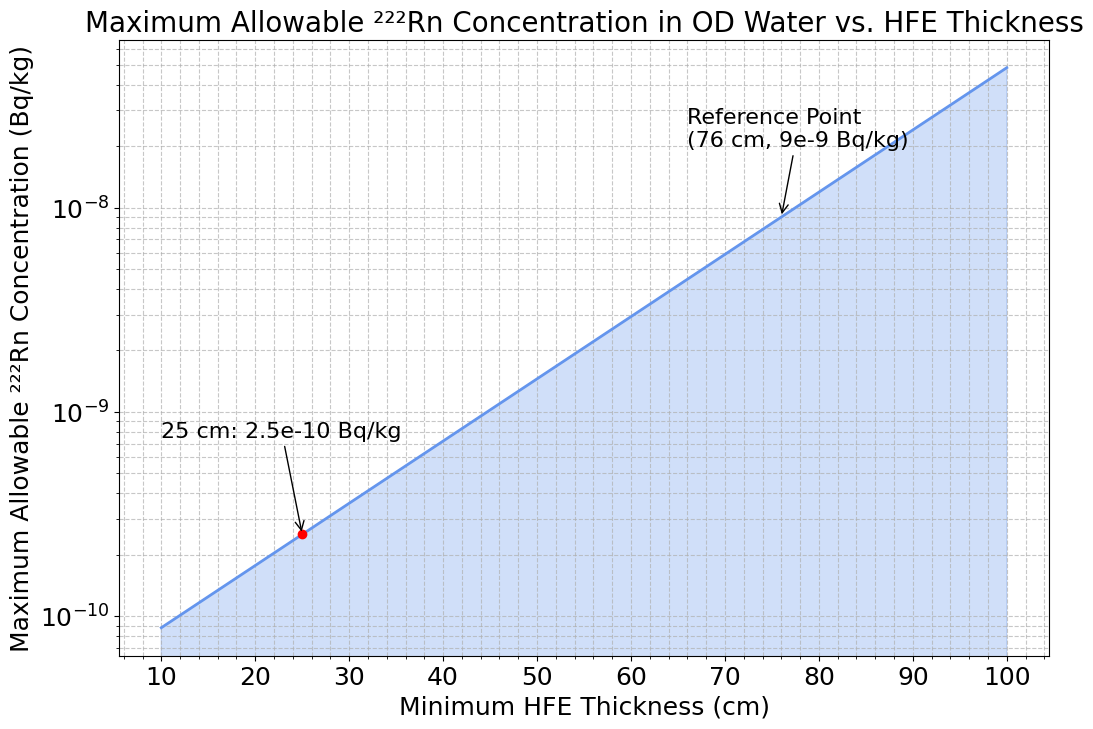

Maximum allowable ²²²Rn concentrations:
 At 76 cm (reference): 9.0e-9 Bq/kg
 At 25 cm: 2.5e-10 Bq/kg
 At 100 cm: 4.8e-08 Bq/kg


In [12]:
# Radon attenuation

# Constants
HFE_DENSITY = 1.73012619  # g/cm^3 for HFE-7200 at 165 K
MASS_ATTENUATION_COEFF = 0.03898  # cm^2/g for 2.5 MeV gamma in HFE-7200
REFERENCE_THICKNESS = 76  # cm
REFERENCE_CONCENTRATION = 9e-9  # Bq/kg


def calculate_max_rn_concentration(thickness):
    """Calculate maximum allowable Rn-222 concentration for a given HFE thickness."""
    attenuation_ratio = np.exp(
        -MASS_ATTENUATION_COEFF * HFE_DENSITY * (REFERENCE_THICKNESS - thickness)
    )
    return REFERENCE_CONCENTRATION * attenuation_ratio


# Calculate data
thicknesses = np.linspace(10, 100, 91)
concentrations = [calculate_max_rn_concentration(t) for t in thicknesses]
concentration_at_25cm = calculate_max_rn_concentration(25)

# Plot
fig, ax = plt.subplots()
ax.plot(thicknesses, concentrations, color="cornflowerblue", linewidth=2)
ax.fill_between(thicknesses, concentrations, alpha=0.3, color="cornflowerblue")
ax.plot(25, concentration_at_25cm, "ro")

ax.set_xlabel("Minimum HFE Thickness (cm)")
ax.set_ylabel("Maximum Allowable ²²²Rn Concentration (Bq/kg)")
ax.set_title("Maximum Allowable ²²²Rn Concentration in OD Water vs. HFE Thickness")

ax.set_yscale("log")
ax.set_xticks(np.arange(10, 101, 10))

# Annotations
ax.annotate(
    f"Reference Point\n(76 cm, 9e-9 Bq/kg)",
    xy=(76, 9e-9),
    xytext=(66, 2e-8),
    arrowprops=dict(arrowstyle="->"),
)
ax.annotate(
    f"25 cm: {concentration_at_25cm:.1e} Bq/kg",
    xy=(25, concentration_at_25cm),
    xytext=(10, concentration_at_25cm * 3),
    arrowprops=dict(arrowstyle="->"),
)

plt.show()

# Print results
print("Maximum allowable ²²²Rn concentrations:")
print(f" At 76 cm (reference): 9.0e-9 Bq/kg")
print(f" At 25 cm: {calculate_max_rn_concentration(25):.1e} Bq/kg")
print(f" At 100 cm: {calculate_max_rn_concentration(100):.1e} Bq/kg")

In [1]:
def calculate_energy(mass_kg, specific_heat_J_per_kg_K, delta_T_K=1):
    return mass_kg * specific_heat_J_per_kg_K * delta_T_K / 1000  # Convert to kJ


# Component data: (name, mass in kg, specific heat in J/kg/K)
components = [
    ("LXe", 5000, 350),
    ("HFE-7200 (original)", 32000, 1250),
    ("HFE-7200 (reduced)", 12800, 1250),
    ("Cryostat Inner Vessel (Ni)", 1681, 444),
]

print(
    "Component                  | Mass (kg) | Specific Heat (J/kg/K) | Energy for 1K (kJ)"
)
print(
    "---------------------------|-----------|------------------------|--------------------"
)

for name, mass, specific_heat in components:
    energy_kJ = calculate_energy(mass, specific_heat)
    print(f"{name:<26} | {mass:>9,d} | {specific_heat:>21,d} | {energy_kJ:>19,.0f}")

# Calculate and print total energy
total_energy = sum(
    calculate_energy(mass, specific_heat) for _, mass, specific_heat in components
)
print("-" * 80)
print(f"{'Total':26} |           |                      | {total_energy:>19,.0f}")

Component                  | Mass (kg) | Specific Heat (J/kg/K) | Energy for 1K (kJ)
---------------------------|-----------|------------------------|--------------------
LXe                        |     5,000 |                   350 |               1,750
HFE-7200 (original)        |    32,000 |                 1,250 |              40,000
HFE-7200 (reduced)         |    12,800 |                 1,250 |              16,000
Cryostat Inner Vessel (Ni) |     1,681 |                   444 |                 746
--------------------------------------------------------------------------------
Total                      |           |                      |              58,496


In [2]:
#!/usr/bin/env python3
"""
This script calculates the cooldown energy and time for the 12.8-tonne HFE configuration.
It uses the following component data (from Table~\ref{tab:energy_table_opt}):
  - LXe: mass = 5000 kg, specific heat = 350 J/(kg·K)
  - HFE-7200: mass = 12800 kg, specific heat = 1250 J/(kg·K)
  - Copper TPC: mass = 566 kg, specific heat = 385 J/(kg·K)
  - IV Carbon Composite: mass = 644 kg, specific heat = 710 J/(kg·K)
  
The total energy per Kelvin is computed by summing the energy required for a 1 K change 
for each component. Then, using the temperature difference (300 K to 165 K) and a 
cooling power of 3 kW, the total cooldown time is computed.
"""

# Component data: mass (kg) and specific heat (J/kg/K)
components = {
    "LXe": {"mass": 5000, "c": 350},
    "HFE-7200": {"mass": 12800, "c": 1250},
    "Copper TPC": {"mass": 566, "c": 385},
    "IV Carbon Composite": {"mass": 644, "c": 710},
}

# Calculate energy required to raise the temperature of each component by 1K (in Joules)
energy_per_K = {}
for comp, data in components.items():
    energy = data["mass"] * data["c"]
    energy_per_K[comp] = energy
    print(f"{comp}: {energy/1e3:.2f} kJ/K")

# Total energy capacity per Kelvin (Joules per Kelvin)
total_energy_per_K = sum(energy_per_K.values())
print(f"\nTotal energy per 1K: {total_energy_per_K/1e6:.3f} MJ/K")

# Temperature difference (from room temperature to operating temperature)
T_initial = 300   # K
T_final = 165     # K
delta_T = T_initial - T_final
print(f"Temperature difference (ΔT): {delta_T} K")

# Total cooldown energy (Joules)
E_cooldown = total_energy_per_K * delta_T
print(f"Total cooldown energy: {E_cooldown/1e9:.3f} GJ")

# Cooling power in Watts (3 kW)
P_cool = 3000  # W

# Cooldown time in seconds and hours
cooldown_time_sec = E_cooldown / P_cool
cooldown_time_hours = cooldown_time_sec / 3600

print(f"Cooldown time: {cooldown_time_sec:.0f} s (~{cooldown_time_hours:.1f} hours)")


LXe: 1750.00 kJ/K
HFE-7200: 16000.00 kJ/K
Copper TPC: 217.91 kJ/K
IV Carbon Composite: 457.24 kJ/K

Total energy per 1K: 18.425 MJ/K
Temperature difference (ΔT): 135 K
Total cooldown energy: 2.487 GJ
Cooldown time: 829132 s (~230.3 hours)


Estimated specific heat of nickel at 165 K:
Molar specific heat: 18.8699 J/(mol·K)
Mass specific heat: 0.3215 J/(g·K)

Calculated specific heat at room temperature (298 K):
Molar specific heat: 24.4912 J/(mol·K)
Mass specific heat: 0.4173 J/(g·K)
Known experimental value: ~0.44 J/(g·K)


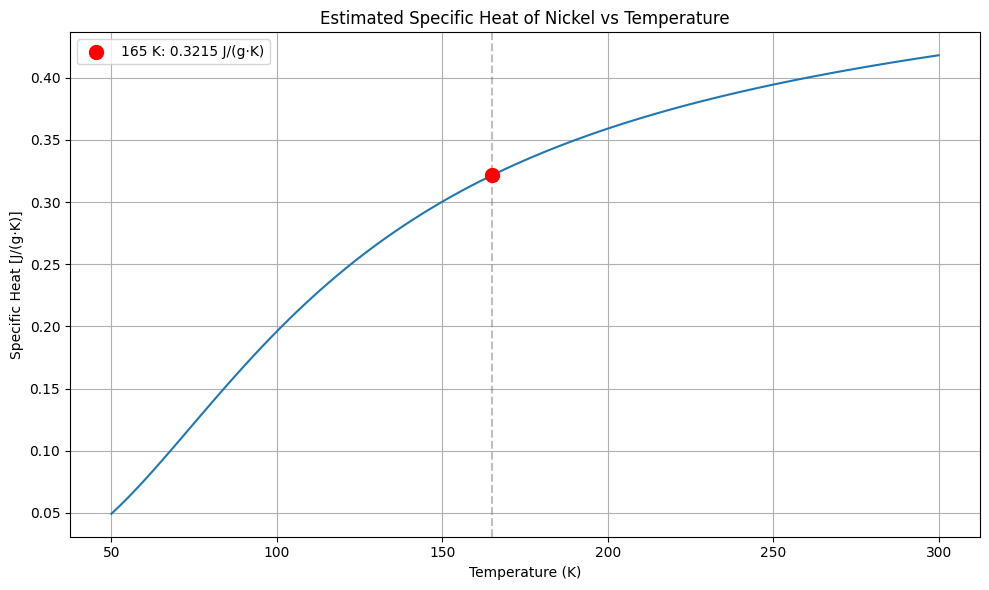

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Constants
k_B = 1.380649e-23  # Boltzmann constant in J/K
N_A = 6.02214076e23  # Avogadro's number
R = 8.314462618  # Gas constant in J/(mol·K)

# Nickel properties
atomic_weight = 58.69  # g/mol
theta_D = 450  # Debye temperature for nickel in K
gamma = 7.3e-3  # Electronic specific heat coefficient in J/(mol·K²)

def debye_function(x):
    """Debye function for specific heat calculation"""
    return (x**4 * np.exp(x)) / ((np.exp(x) - 1)**2)

def lattice_specific_heat(T):
    """Calculate lattice contribution to specific heat using Debye model"""
    x_upper = theta_D / T
    integral, _ = quad(debye_function, 0, x_upper)
    return 9 * R * ((T / theta_D)**3) * integral

def electronic_specific_heat(T):
    """Calculate electronic contribution to specific heat"""
    return gamma * T

def total_specific_heat(T):
    """Calculate total specific heat in J/(mol·K)"""
    return lattice_specific_heat(T) + electronic_specific_heat(T)

# Calculate specific heat at 165 K
T_target = 165  # K
C_p_molar = total_specific_heat(T_target)
C_p_mass = C_p_molar / atomic_weight  # Convert to J/(g·K)

print(f"Estimated specific heat of nickel at {T_target} K:")
print(f"Molar specific heat: {C_p_molar:.4f} J/(mol·K)")
print(f"Mass specific heat: {C_p_mass:.4f} J/(g·K)")

# Compare with known room temperature value
T_room = 298  # K
C_p_room = total_specific_heat(T_room)
C_p_room_mass = C_p_room / atomic_weight
print(f"\nCalculated specific heat at room temperature ({T_room} K):")
print(f"Molar specific heat: {C_p_room:.4f} J/(mol·K)")
print(f"Mass specific heat: {C_p_room_mass:.4f} J/(g·K)")
print(f"Known experimental value: ~0.44 J/(g·K)")

# Plot specific heat vs temperature
temperatures = np.linspace(50, 300, 100)
specific_heats = [total_specific_heat(T) / atomic_weight for T in temperatures]

plt.figure(figsize=(10, 6))
plt.plot(temperatures, specific_heats)
plt.scatter([T_target], [C_p_mass], color='red', s=100, zorder=5, label=f'165 K: {C_p_mass:.4f} J/(g·K)')
plt.xlabel('Temperature (K)')
plt.ylabel('Specific Heat [J/(g·K)]')
plt.title('Estimated Specific Heat of Nickel vs Temperature')
plt.grid(True)
plt.axvline(x=T_target, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()